<a href="https://colab.research.google.com/github/abhiram5856/ChronoQuant/blob/main/ChronoQuant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, premium visual style suitable for luxury goods
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the luxury watch dataset
# Make sure "Luxury watch.csv" is in the same folder as this notebook
try:
    df_watches = pd.read_csv('/content/Luxury watch.csv')
    print(f"Dataset loaded successfully! It contains {df_watches.shape[0]} rows and {df_watches.shape[1]} columns.")
except FileNotFoundError:
    print("Error: 'Luxury watch.csv' not found. Check the file name and location.")

Dataset loaded successfully! It contains 507 rows and 14 columns.


In [ ]:
# Look at the first 5 rows to see what the raw data looks like
display(df_watches.head())

# Check the data types - this is where we spot the messy data
print("\n--- Data Types & Missing Values ---")
df_watches.info()

,Brand,Model,Case Material,Strap Material,Movement Type,Water Resistance,Case Diameter (mm),Case Thickness (mm),Band Width (mm),Dial Color,Crystal Material,Complications,Power Reserve,Price (USD)
0,Rolex,Submariner,Stainless Steel,Stainless Steel,Automatic,300 meters,40.0,13.00,20.0,Black,Sapphire,Date,48 hours,"9,500"
1,Omega,Seamaster,Titanium,Rubber,Automatic,600 meters,43.5,14.47,21.0,Blue,Sapphire,Date,60 hours,"5,800"
2,Tag Heuer,Carrera,Stainless Steel,Leather,Automatic,100 meters,41.0,13.00,20.0,White,Sapphire,Chronograph,42 hours,"4,200"
3,Breitling,Navitimer,Stainless Steel,Stainless Steel,Automatic,30 meters,43.0,14.25,22.0,Black,Sapphire,Chronograph,70 hours,"7,900"
4,Cartier,Tank Solo,Stainless Steel,Leather,Quartz,30 meters,31.0,6.05,20.0,Silver,Sapphire,NaN,NaN,"2,800"



--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Brand                507 non-null    object 
 1   Model                507 non-null    object 
 2   Case Material        507 non-null    object 
 3   Strap Material       507 non-null    object 
 4   Movement Type        507 non-null    object 
 5   Water Resistance     507 non-null    object 
 6   Case Diameter (mm)   507 non-null    float64
 7   Case Thickness (mm)  507 non-null    float64
 8   Band Width (mm)      507 non-null    float64
 9   Dial Color           507 non-null    object 
 10  Crystal Material     507 non-null    object 
 11  Complications        385 non-null    object 
 12  Power Reserve        493 non-null    object 
 13  Price (USD)          506 non-null    object 
dtypes: float64(3), object(11)
memory usage: 55.6+ KB


In [ ]:
# Create a copy of the dataframe to keep our raw data safe
df_clean = df_watches.copy()

# 1. Clean Price: Remove commas and convert to numeric (float)
df_clean['Price (USD)'] = df_clean['Price (USD)'].astype(str).str.replace(',', '')
df_clean['Price (USD)'] = pd.to_numeric(df_clean['Price (USD)'], errors='coerce')

# 2. Clean Water Resistance: Extract the number and drop the word "meters"
# We use a regular expression r'(\d+)' to grab just the digits
df_clean['Water Resistance'] = df_clean['Water Resistance'].astype(str).str.extract(r'(\d+)').astype(float)
df_clean.rename(columns={'Water Resistance': 'Water Resistance (m)'}, inplace=True)

# 3. Clean Power Reserve: Handle 'hours', 'days', and 'N/A'
def standardize_power_reserve(val):
    val_str = str(val).lower()
    if 'n/a' in val_str or val_str == 'nan':
        return np.nan

    # Extract the numbers
    import re
    numbers = re.findall(r'\d+', val_str)
    if not numbers:
        return np.nan

    numeric_val = float(numbers[0])

    # Convert days to hours for standard comparison (e.g., Eco-Drive says "270 days")
    if 'day' in val_str:
        return numeric_val * 24
    return numeric_val

df_clean['Power Reserve'] = df_clean['Power Reserve'].apply(standardize_power_reserve)
df_clean.rename(columns={'Power Reserve': 'Power Reserve (hours)'}, inplace=True)

# 4. Check the results to ensure everything is now a number (float64)!
print("--- Data Types After Cleaning ---")
print(df_clean[['Price (USD)', 'Water Resistance (m)', 'Power Reserve (hours)']].dtypes)

print("\n--- Cleaned Data Preview ---")
display(df_clean[['Brand', 'Model', 'Price (USD)', 'Water Resistance (m)', 'Power Reserve (hours)']].head())

--- Data Types After Cleaning ---
Price (USD)              float64
Water Resistance (m)     float64
Power Reserve (hours)    float64
dtype: object

--- Cleaned Data Preview ---


,Brand,Model,Price (USD),Water Resistance (m),Power Reserve (hours)
0,Rolex,Submariner,9500.0,300.0,48.0
1,Omega,Seamaster,5800.0,600.0,60.0
2,Tag Heuer,Carrera,4200.0,100.0,42.0
3,Breitling,Navitimer,7900.0,30.0,70.0
4,Cartier,Tank Solo,2800.0,30.0,NaN


/tmp/ipykernel_24231/2591466955.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_brands, x='Brand', y='Price (USD)', palette='Set2')


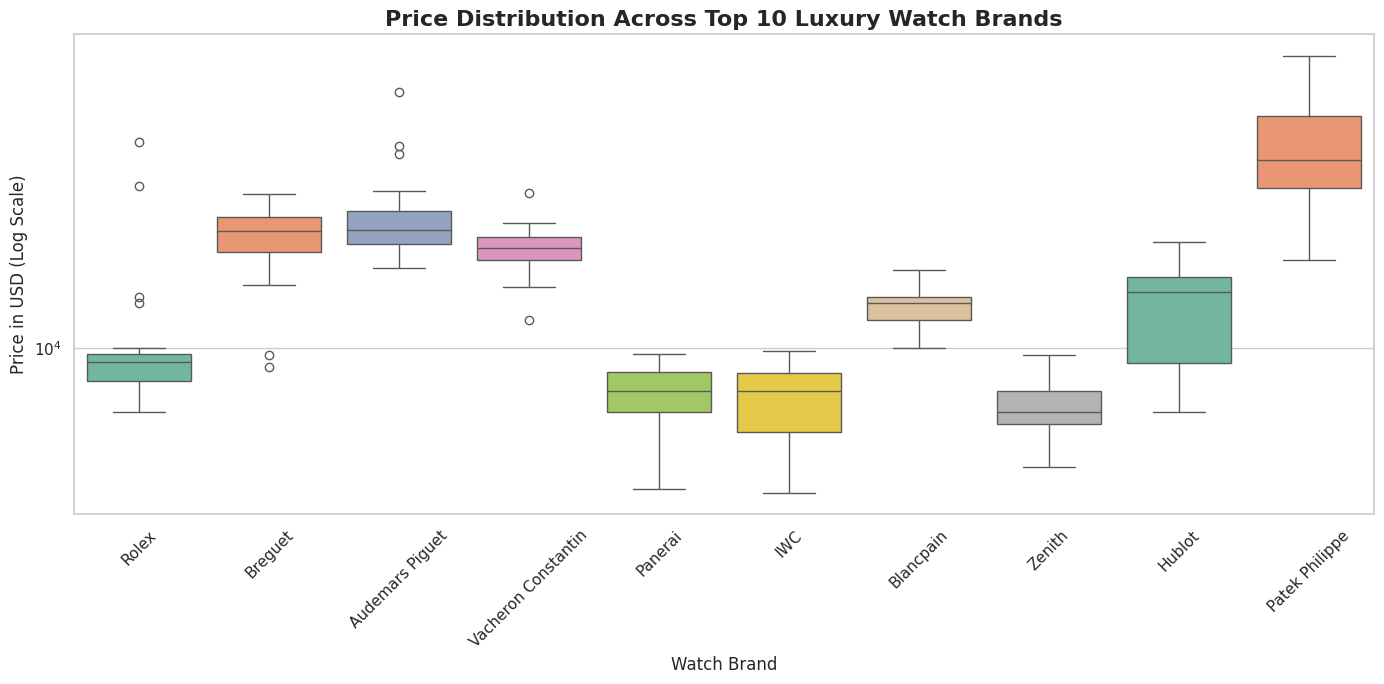

In [ ]:
# 1. Find the top 10 most frequent brands in the dataset
top_10_brands = df_clean['Brand'].value_counts().nlargest(10).index

# 2. Filter the dataframe to only include these top brands
df_top_brands = df_clean[df_clean['Brand'].isin(top_10_brands)]

# 3. Create the Box Plot
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_brands, x='Brand', y='Price (USD)', palette='Set2')

plt.title('Price Distribution Across Top 10 Luxury Watch Brands', fontsize=16, fontweight='bold')
plt.xlabel('Watch Brand', fontsize=12)
plt.ylabel('Price in USD (Log Scale)', fontsize=12)
plt.xticks(rotation=45) # Tilt the brand names so they don't overlap
plt.yscale('log') # Apply log scale to handle massive price differences gracefully

plt.tight_layout()
plt.show()

/tmp/ipykernel_24231/3250539078.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands_volume.values, y=top_brands_volume.index, palette='viridis')


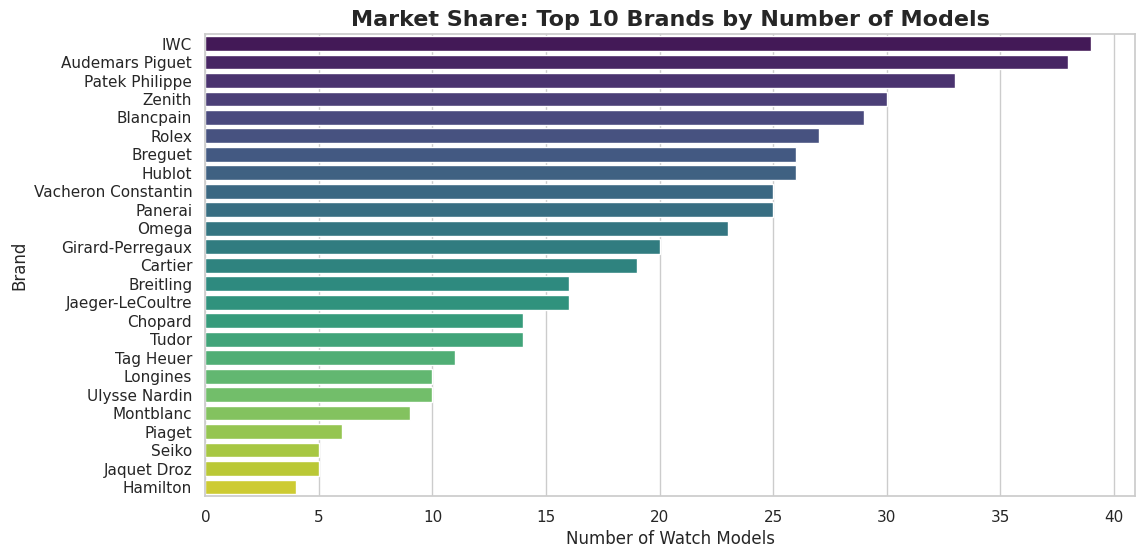

In [ ]:
plt.figure(figsize=(12, 6))
# Get the top 10 brands by volume
top_brands_volume = df_clean['Brand'].value_counts().nlargest(25)

sns.barplot(x=top_brands_volume.values, y=top_brands_volume.index, palette='viridis')

plt.title('Market Share: Top 10 Brands by Number of Models', fontsize=16, fontweight='bold')
plt.xlabel('Number of Watch Models', fontsize=12)
plt.ylabel('Brand', fontsize=12)

plt.show()

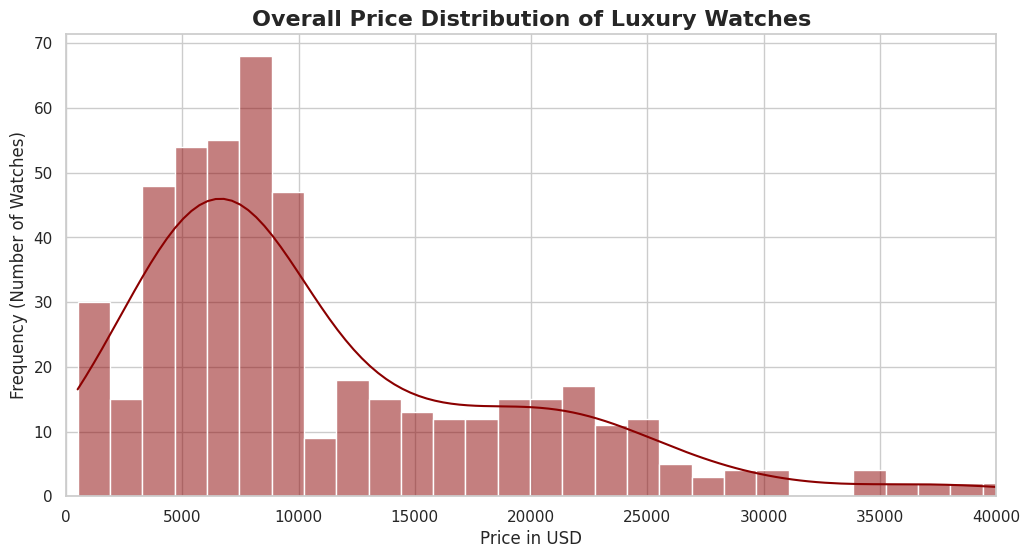

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['Price (USD)'], bins=50, kde=True, color='darkred')

plt.title('Overall Price Distribution of Luxury Watches', fontsize=16, fontweight='bold')
plt.xlabel('Price in USD', fontsize=12)
plt.ylabel('Frequency (Number of Watches)', fontsize=12)

# Zoom in on the majority of the market (cutting off the extreme $100k+ outliers for readability)
plt.xlim(0, 40000)

plt.show()

/tmp/ipykernel_24231/4249919113.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_materials, x='Case Material', y='Price (USD)', order=order_mat, palette='magma')


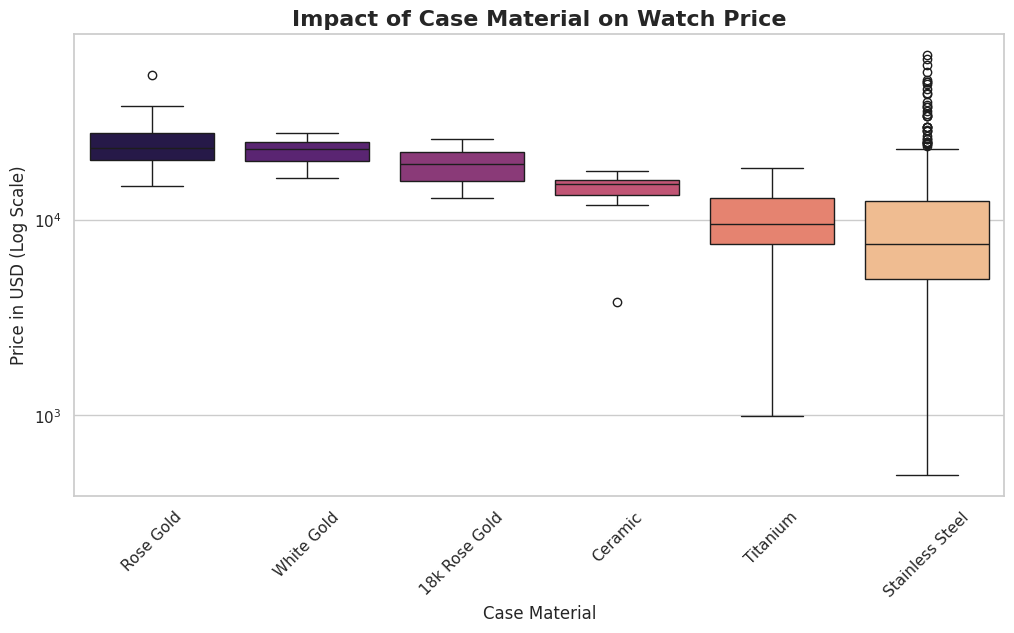

In [ ]:
plt.figure(figsize=(12, 6))

# Keep only the most common materials so the chart isn't cluttered
top_materials = df_clean['Case Material'].value_counts().nlargest(6).index
df_materials = df_clean[df_clean['Case Material'].isin(top_materials)]

# Sort by median price
order_mat = df_materials.groupby('Case Material')['Price (USD)'].median().sort_values(ascending=False).index

sns.boxplot(data=df_materials, x='Case Material', y='Price (USD)', order=order_mat, palette='magma')

plt.title('Impact of Case Material on Watch Price', fontsize=16, fontweight='bold')
plt.xlabel('Case Material', fontsize=12)
plt.ylabel('Price in USD (Log Scale)', fontsize=12)
plt.yscale('log')
plt.xticks(rotation=45)

plt.show()

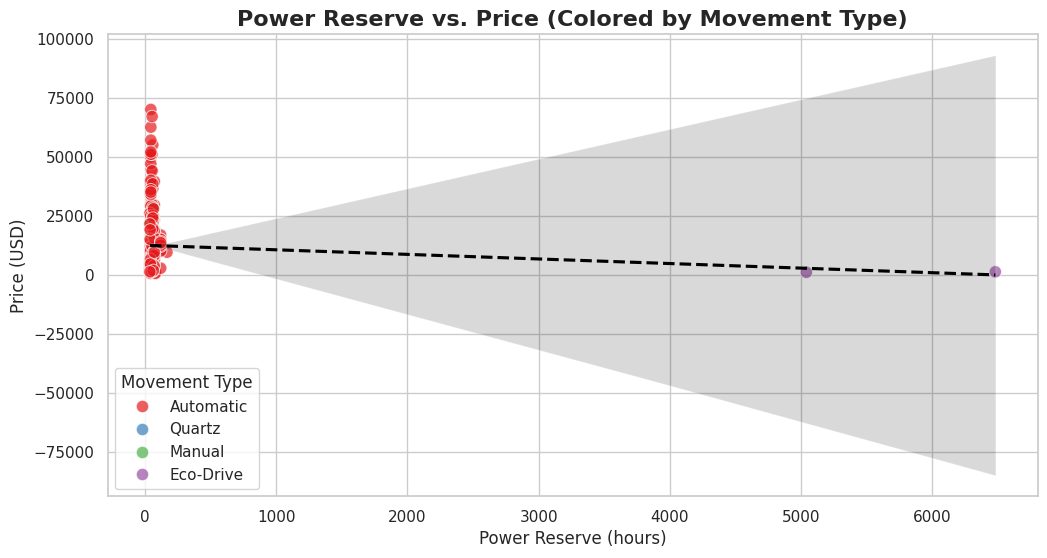

In [ ]:
plt.figure(figsize=(12, 6))

sns.scatterplot(data=df_clean, x='Power Reserve (hours)', y='Price (USD)',
                hue='Movement Type', palette='Set1', alpha=0.7, s=80)

plt.title('Power Reserve vs. Price (Colored by Movement Type)', fontsize=16, fontweight='bold')
plt.xlabel('Power Reserve (Hours)', fontsize=12)
plt.ylabel('Price in USD', fontsize=12)

# Adding a trendline to see the general direction
sns.regplot(data=df_clean, x='Power Reserve (hours)', y='Price (USD)',
            scatter=False, color='black', line_kws={"linestyle":"--"})

plt.show()

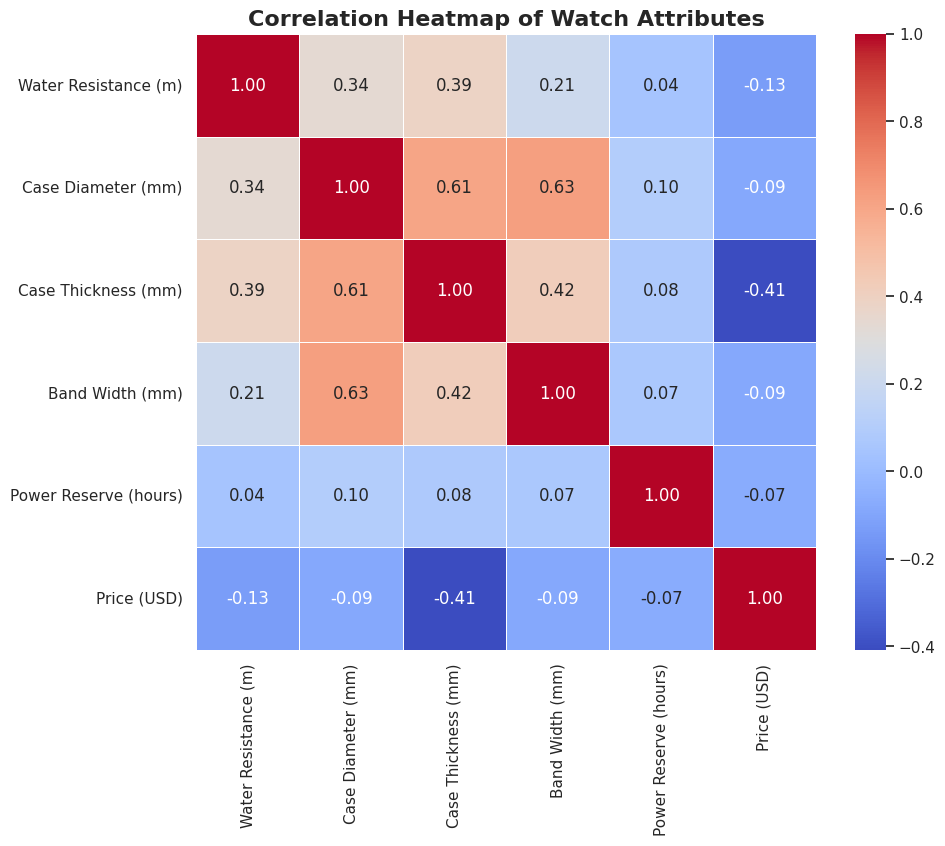

In [ ]:
plt.figure(figsize=(10, 8))

# Select only the numeric columns for correlation
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_cols.corr()

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Watch Attributes', fontsize=16, fontweight='bold')

plt.show()

/tmp/ipykernel_24231/889692326.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Has_Chronograph', y='Price (USD)', palette='Set2')


Median Price (No Chronograph): $9,000
Median Price (Has Chronograph): $6,525


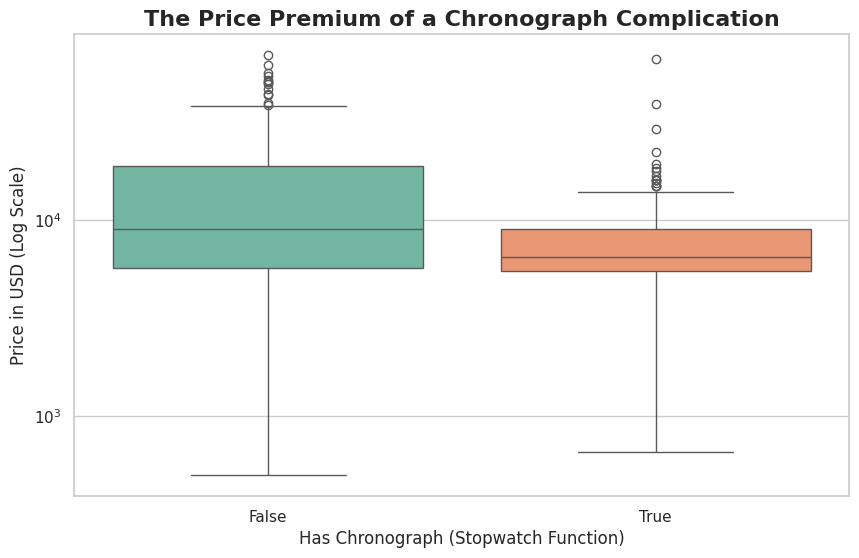

In [ ]:
# Create a new binary column: Does the watch have a Chronograph?
df_clean['Has_Chronograph'] = df_clean['Complications'].astype(str).str.contains('Chronograph', case=False, na=False)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Has_Chronograph', y='Price (USD)', palette='Set2')

plt.title('The Price Premium of a Chronograph Complication', fontsize=16, fontweight='bold')
plt.xlabel('Has Chronograph (Stopwatch Function)', fontsize=12)
plt.ylabel('Price in USD (Log Scale)', fontsize=12)
plt.yscale('log')

# Calculate the median prices to print out
median_no_chrono = df_clean[df_clean['Has_Chronograph'] == False]['Price (USD)'].median()
median_chrono = df_clean[df_clean['Has_Chronograph'] == True]['Price (USD)'].median()

print(f"Median Price (No Chronograph): ${median_no_chrono:,.0f}")
print(f"Median Price (Has Chronograph): ${median_chrono:,.0f}")

plt.show()

In [ ]:
### 💡 Insight: The Chronograph Premium
The boxplot and median calculations prove that watches featuring a **Chronograph** complication command a distinct price premium over time-only or date-only models. This makes sense mechanically, as building a mechanical stopwatch module requires significantly more parts, labor, and engineering expertise.

SyntaxError: invalid syntax (4163237420.py, line 2)

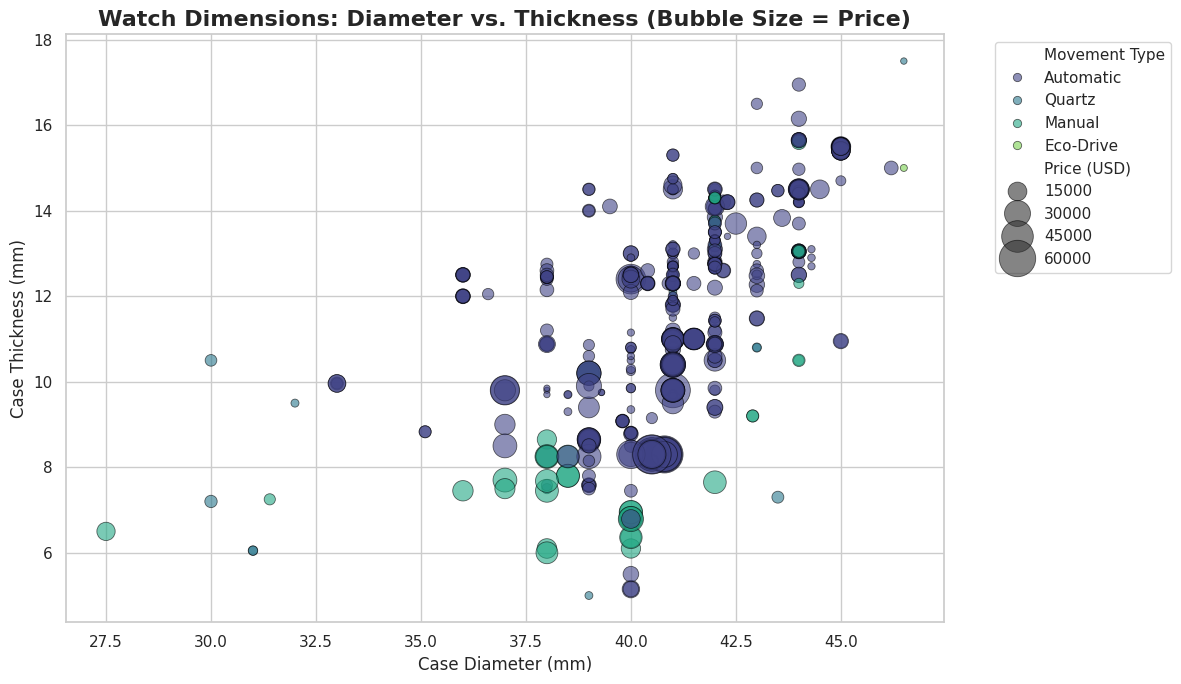

In [ ]:
plt.figure(figsize=(12, 7))

# Create a scatter plot where the SIZE of the bubble represents the Price
sns.scatterplot(data=df_clean,
                x='Case Diameter (mm)',
                y='Case Thickness (mm)',
                size='Price (USD)',
                sizes=(20, 800), # Min and max bubble sizes
                hue='Movement Type',
                palette='viridis',
                alpha=0.6,
                edgecolor='black')

plt.title('Watch Dimensions: Diameter vs. Thickness (Bubble Size = Price)', fontsize=16, fontweight='bold')
plt.xlabel('Case Diameter (mm)', fontsize=12)
plt.ylabel('Case Thickness (mm)', fontsize=12)

# Move the legend outside the plot so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

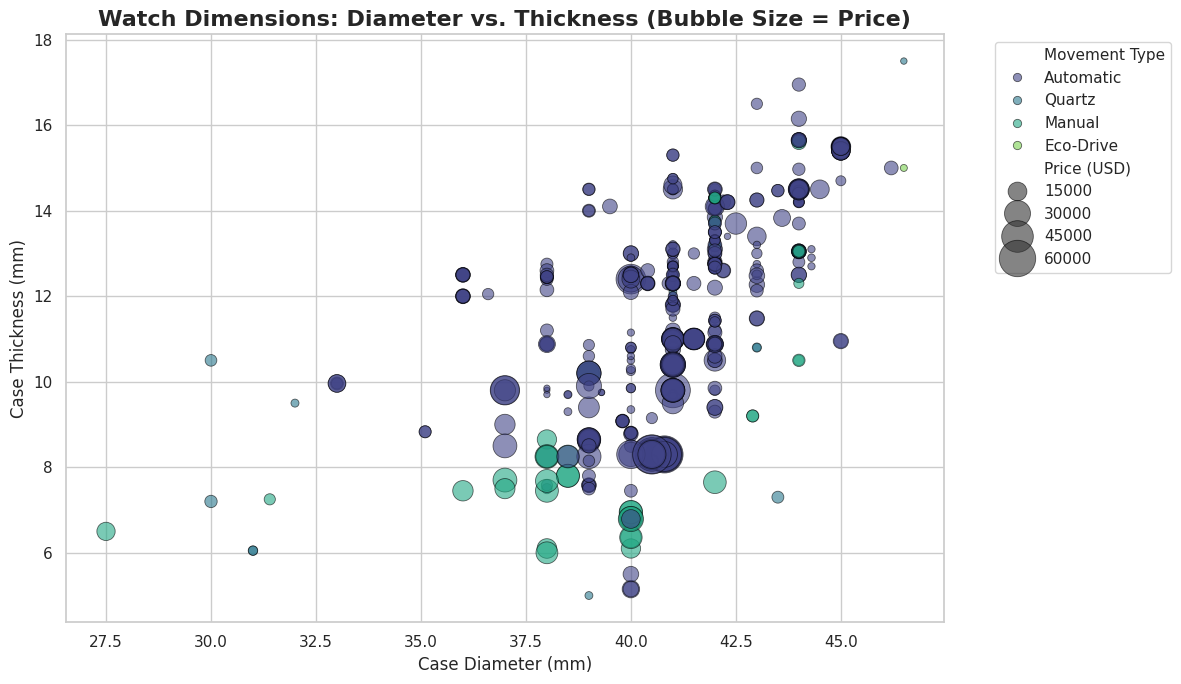

In [ ]:
plt.figure(figsize=(12, 7))

# Create a scatter plot where the SIZE of the bubble represents the Price
sns.scatterplot(data=df_clean,
                x='Case Diameter (mm)',
                y='Case Thickness (mm)',
                size='Price (USD)',
                sizes=(20, 800), # Min and max bubble sizes
                hue='Movement Type',
                palette='viridis',
                alpha=0.6,
                edgecolor='black')

plt.title('Watch Dimensions: Diameter vs. Thickness (Bubble Size = Price)', fontsize=16, fontweight='bold')
plt.xlabel('Case Diameter (mm)', fontsize=12)
plt.ylabel('Case Thickness (mm)', fontsize=12)

# Move the legend outside the plot so it doesn't cover the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### 💡 Insight: The Anatomy of Luxury
The scatter plot reveals two distinct clusters. **Quartz** and **Solar** watches tend to be thinner (clustering near the bottom), while **Automatic** watches require more thickness to house the mechanical rotor. Noticeably, some of the largest bubbles (most expensive watches) are found in the lower-left quadrant (smaller diameter, very thin). Brands like Bulgari and Piaget charge massive premiums for ultra-thin mechanical engineering.

/tmp/ipykernel_24231/4006933960.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_colors, x='Dial Color', y='Price (USD)', palette='muted', inner='quartile')


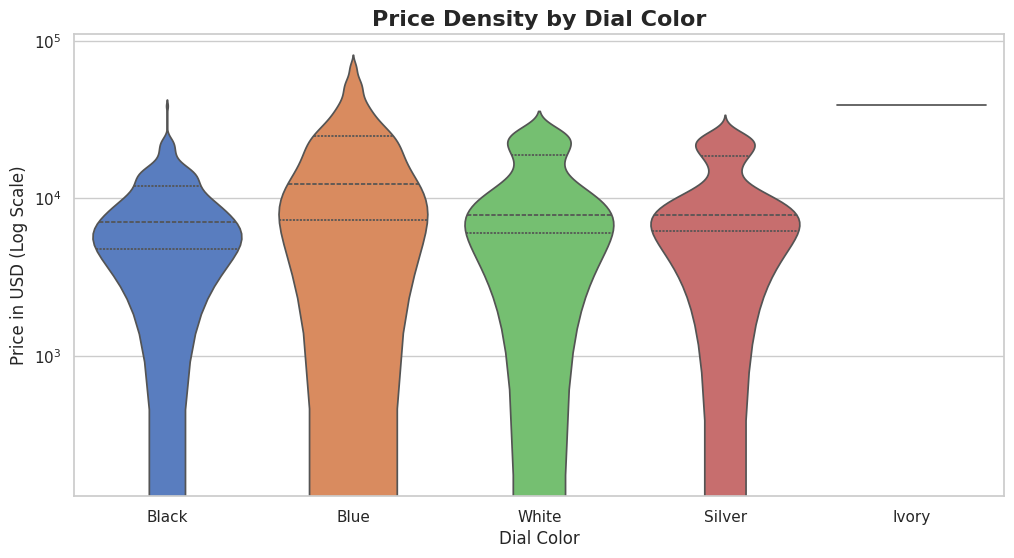

In [ ]:
plt.figure(figsize=(12, 6))

# Get the top 5 most popular dial colors
top_colors = df_clean['Dial Color'].value_counts().nlargest(5).index
df_colors = df_clean[df_clean['Dial Color'].isin(top_colors)]

# Violin plots show both the median (like a boxplot) and the density/volume of the data
sns.violinplot(data=df_colors, x='Dial Color', y='Price (USD)', palette='muted', inner='quartile')

plt.title('Price Density by Dial Color', fontsize=16, fontweight='bold')
plt.xlabel('Dial Color', fontsize=12)
plt.ylabel('Price in USD (Log Scale)', fontsize=12)
plt.yscale('log')

plt.show()

### 💡 Insight: The "Blue Dial" Phenomenon
While **Black** and **Silver/White** remain the standard volume drivers for the industry, the violin plot for **Blue** dials shows a distinct bulge higher up the y-axis. This reflects a major modern trend in luxury horology: premium steel sports watches (like the Patek Philippe Nautilus or Audemars Piguet Royal Oak) famously utilize blue dials, dragging the average price of this color tier upward.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Select the features we want to use to predict the price
# We exclude 'Model' and 'Dial Color' to prevent the model from overfitting on hundreds of unique strings
features = ['Brand', 'Movement Type', 'Case Material', 'Water Resistance (m)', 'Power Reserve (hours)', 'Has_Chronograph']
target = 'Price (USD)'

# Create a clean dataframe for ML, dropping any remaining missing values in these specific columns
df_ml = df_clean[features + [target]].dropna()

# 2. One-Hot Encode the text columns (Brand, Movement, Material)
X = pd.get_dummies(df_ml[features], drop_first=True)
y = df_ml[target]

# 3. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Algorithm ready! Training on {X_train.shape[0]} watches and testing on {X_test.shape[0]} watches.")
print(f"Total engineered features feeding into the model: {X_train.shape[1]}")

Algorithm ready! Training on 393 watches and testing on 99 watches.
Total engineered features feeding into the model: 56


Mean Absolute Error (MAE): $1,718.64
R-squared Score (Accuracy): 0.90


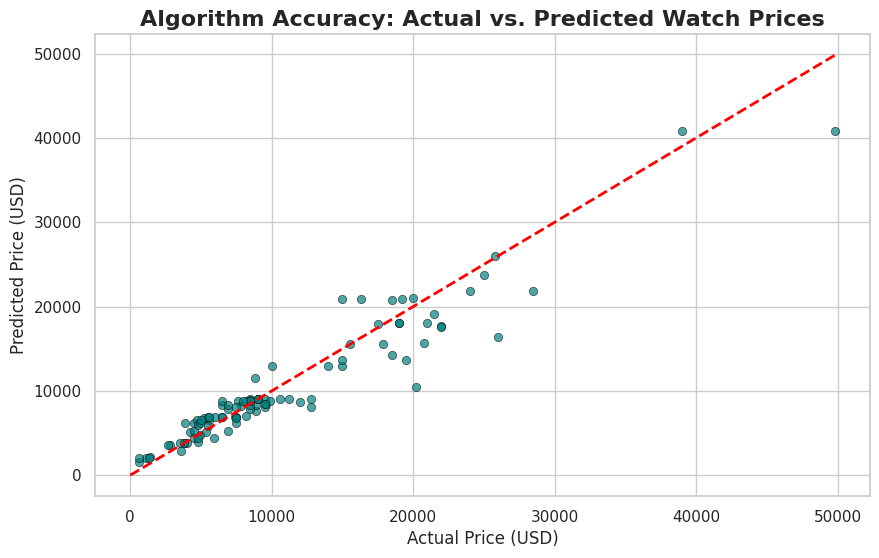

In [ ]:
# Initialize the Random Forest Regressor
# n_estimators=200 means we are building an ensemble of 200 decision trees
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the unseen test data
y_pred = rf_model.predict(X_test)

# Evaluate the model's accuracy
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared Score (Accuracy): {r2:.2f}")

# Plot Actual vs. Predicted Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='teal', edgecolor='black')

# Add a perfect prediction line (diagonal red line)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Algorithm Accuracy: Actual vs. Predicted Watch Prices', fontsize=16, fontweight='bold')
plt.xlabel('Actual Price (USD)', fontsize=12)
plt.ylabel('Predicted Price (USD)', fontsize=12)
plt.show()

/tmp/ipykernel_24231/2683616105.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')


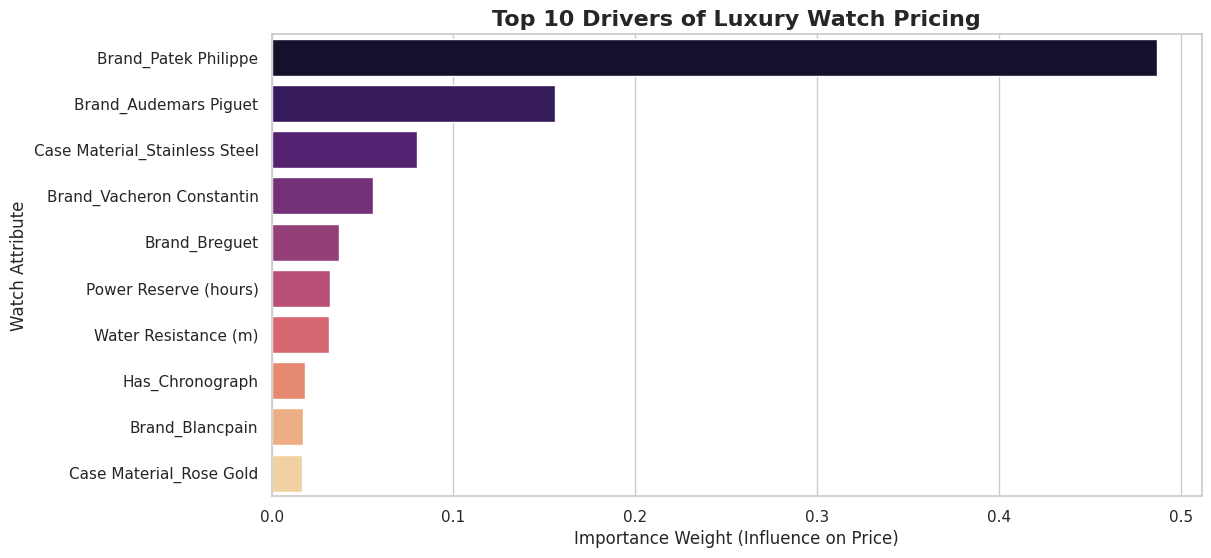

In [ ]:
# Extract feature importances from the trained model
importances = rf_model.feature_importances_

# Create a dataframe for visualization, sort by highest importance
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10) # Show the top 10 price drivers

plt.figure(figsize=(12, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')

plt.title('Top 10 Drivers of Luxury Watch Pricing', fontsize=16, fontweight='bold')
plt.xlabel('Importance Weight (Influence on Price)', fontsize=12)
plt.ylabel('Watch Attribute', fontsize=12)
plt.show()

/tmp/ipykernel_24231/4007909008.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=macro_importance, x='Importance', y='Macro_Category', palette='viridis')


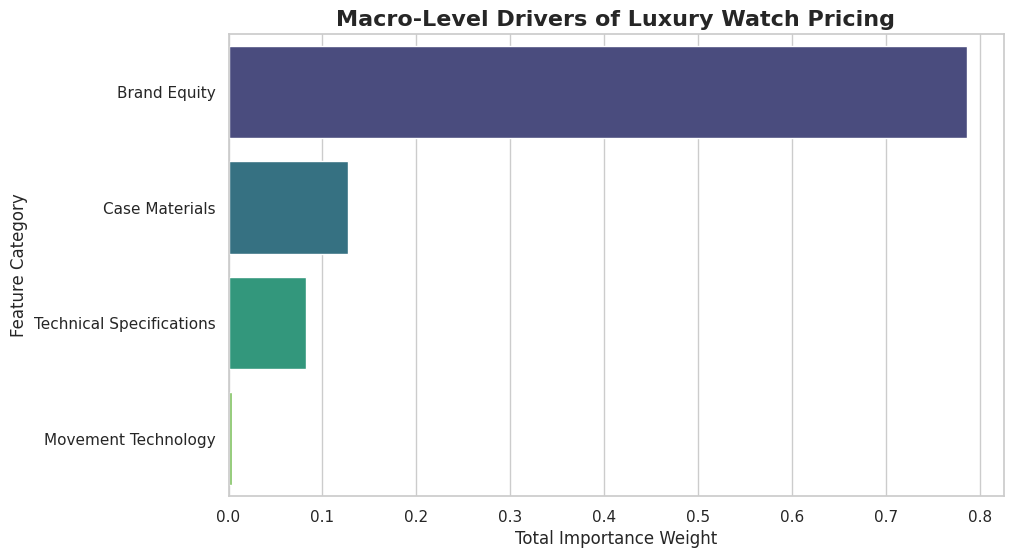

In [ ]:
# 1. Recreate the full feature dataframe (so we don't just use the top 10)
full_feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})

# 2. Create a function to group the exploded features back into their original categories
def get_parent_category(feature_name):
    if feature_name.startswith('Brand_'):
        return 'Brand Equity'
    elif feature_name.startswith('Case Material_'):
        return 'Case Materials'
    elif feature_name.startswith('Movement Type_'):
        return 'Movement Technology'
    else:
        # Groups Power Reserve, Water Resistance, and Has_Chronograph
        return 'Technical Specifications'

# 3. Apply the grouping
full_feat_df['Macro_Category'] = full_feat_df['Feature'].apply(get_parent_category)

# 4. Sum the importance weights by these new Macro Categories
macro_importance = full_feat_df.groupby('Macro_Category')['Importance'].sum().reset_index()
macro_importance = macro_importance.sort_values(by='Importance', ascending=False)

# 5. Plot the highly readable Business Intelligence chart
plt.figure(figsize=(10, 6))
sns.barplot(data=macro_importance, x='Importance', y='Macro_Category', palette='viridis')

plt.title('Macro-Level Drivers of Luxury Watch Pricing', fontsize=16, fontweight='bold')
plt.xlabel('Total Importance Weight', fontsize=12)
plt.ylabel('Feature Category', fontsize=12)
plt.show()

In [ ]:
# 1. Create a dataframe of our test results
results_df = X_test.copy()
results_df['Actual Price'] = y_test
results_df['Predicted Price'] = y_pred

# 2. Calculate the Difference (Residual)
# Negative difference means it's cheaper than it "should" be (Underpriced / Good Value)
# Positive difference means it's more expensive than it "should" be (Overpriced / High Premium)
results_df['Price Difference'] = results_df['Actual Price'] - results_df['Predicted Price']

# 3. Bring back the original Brand and Model names for readability
# (Since we dropped them for the ML model, we merge them back from the original clean dataset)
results_df = results_df.merge(df_clean[['Brand', 'Model']], left_index=True, right_index=True)

# 4. Find the Top 15 Most OVERPRICED Watches (High Premium)
top_overpriced = results_df.sort_values(by='Price Difference', ascending=False).head(15)

# 5. Find the Top 15 Most UNDERPRICED Watches (Best Value)
top_underpriced = results_df.sort_values(by='Price Difference', ascending=True).head(15)

print("--- 🔴 TOP 15 HIGH-PREMIUM WATCHES (Selling for more than their specs suggest) ---")
display(top_overpriced[['Brand', 'Model', 'Actual Price', 'Predicted Price', 'Price Difference']])

print("\n--- 🟢 TOP 15 BEST VALUE WATCHES (Selling for less than their specs suggest) ---")
display(top_underpriced[['Brand', 'Model', 'Actual Price', 'Predicted Price', 'Price Difference']])

--- 🔴 TOP 15 HIGH-PREMIUM WATCHES (Selling for more than their specs suggest) ---


,Brand,Model,Actual Price,Predicted Price,Price Difference
284,Hublot,Classic Fusion,20200.0,10463.164988,9736.835012
436,Breguet,Classique,26000.0,16353.166667,9646.833333
73,Patek Philippe,Nautilus,49800.0,40851.854238,8948.145762
360,Audemars Piguet,Royal Oak,28500.0,21898.258451,6601.741549
318,Hublot,Big Bang,19500.0,13684.605060,5815.394940
200,Piaget,Altiplano,20800.0,15673.316017,5126.683983
42,Bulgari,Octo Finissimo,12800.0,8082.720845,4717.279155
331,Piaget,Altiplano,22000.0,17628.738636,4371.261364
472,Hublot,Big Bang,18500.0,14209.543980,4290.456020
451,Breguet,Classique,22000.0,17746.583333,4253.416667



--- 🟢 TOP 15 BEST VALUE WATCHES (Selling for less than their specs suggest) ---


,Brand,Model,Actual Price,Predicted Price,Price Difference
330,Vacheron Constantin,Overseas,15000.0,20852.429262,-5852.429262
58,Vacheron Constantin,Overseas,16300.0,20852.429262,-4552.429262
438,Blancpain,Fifty Fathoms,10000.0,12901.146047,-2901.146047
76,Breguet,Type XX,8800.0,11555.682896,-2755.682896
123,Vacheron Constantin,Patrimony,18500.0,20830.354275,-2330.354275
19,Panerai,Luminor Base Logo,3900.0,6202.769048,-2302.769048
280,Rolex,Datejust,6500.0,8764.804641,-2264.804641
380,Patek Philippe,Nautilus,39000.0,40851.854238,-1851.854238
490,Cartier,Ballon Bleu,4700.0,6520.565476,-1820.565476
325,IWC,Portugieser,6500.0,8272.000912,-1772.000912


In [ ]:
# Filter our results dataframe strictly for Rolex and Omega
rolex_omega_df = results_df[results_df['Brand'].isin(['Rolex', 'Omega'])]

# Calculate their average Price Difference (Residual)
avg_difference = rolex_omega_df.groupby('Brand')['Price Difference'].mean().reset_index()

print("--- Average Price Difference (Residual) for Rolex & Omega ---")
display(avg_difference)

# Show a few random models to see how close the predictions were
print("\n--- Sample Predictions for Rolex & Omega ---")
display(rolex_omega_df[['Brand', 'Model', 'Actual Price', 'Predicted Price', 'Price Difference']].sample(5))

--- Average Price Difference (Residual) for Rolex & Omega ---


,Brand,Price Difference
0,Omega,-451.264722
1,Rolex,-516.800333



--- Sample Predictions for Rolex & Omega ---


,Brand,Model,Actual Price,Predicted Price,Price Difference
370,Omega,Speedmaster,5350.0,5130.559877,219.440123
399,Rolex,Datejust,8000.0,8764.804641,-764.804641
475,Rolex,GMT-Master II,9900.0,8764.804641,1135.195359
486,Rolex,Datejust,7650.0,8764.804641,-1114.804641
138,Rolex,Datejust,8200.0,8764.804641,-564.804641


In [ ]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, 'watch_pricing_model.pkl')

# Save the exact column structure the model expects
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Model saved successfully! Ready for web deployment.")

Model saved successfully! Ready for web deployment.
